(03-12-consumptie-capm)=

# Lucas, Breeden en de SDF

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1976–1983.

**Wat we al weten.** In [](#01-03-williams-ddm) werd een prijs de contante
waarde van toekomstige dividenden, met een discontovoet die als gegeven werd
aangenomen — en de data lieten zien dat juist die discontovoet beweegt. Het
CAPM gaf een discontovoet per activum, maar alleen in één periode en ten
opzichte van een marktportefeuille die niemand kan waarnemen. In
[](#03-11-apt-no-arbitrage) volgde dat de afwezigheid van arbitrage genoeg is
voor het *bestaan* van een positieve stochastic discount factor $m_{t+1}$ met
$p_t = \E_t[m_{t+1} x_{t+1}]$. Wat die stelling niet zegt, is wélke $m_{t+1}$
het is, en waarom.

**Welke vraag staat open.** Kan de discontofactor aan iets meetbaars worden
vastgeknoopt — zodat de theorie van de discontovoet toetsbaar wordt in plaats
van een restpost?
```

## Overzicht

In 1978 publiceerde Robert Lucas *Asset Prices in an Exchange Economy*
{cite}`Lucas1978`, en daarmee kreeg de discontovoet voor het eerst een
theorie. De *stochastic discount factor* (SDF, stochastische
disconteringsfactor: de willekeurige variabele waarmee je een toekomstige payoff
verdisconteert) is in Lucas' economie geen abstract bestaansobject maar de
verhouding van marginale nutten, $m_{t+1} = \beta u'(c_{t+1})/u'(c_t)$. Een
euro morgen is weinig waard als morgen een goede dag is, en veel als morgen
een slechte dag is — en "goed" en "slecht" meet je aan consumptie. Rubinstein
{cite}`Rubinstein1976` had dezelfde weging twee jaar eerder gebruikt om
onzekere inkomensstromen en opties te waarderen; Breeden {cite}`Breeden1979`
liet zien dat Mertons intertemporele CAPM, met al zijn toestandsvariabelen,
in continue tijd samenvalt tot één bèta: die ten opzichte van consumptie. Dit
werk definieert het tijdvak omdat het de eerste keer is dat de discontovoet uit
een optimalisatieprobleem volgt en daardoor *fout kan zijn*.

Dat laatste is de epistemische wending, en die is het hart van deze lecture.
Bij Williams was $p = \sum \E[d]/(1+r)^j$ een identiteit met een vrije $r$. Bij
Lucas is $r$ niet meer vrij: gegeven $\beta$, $\gamma$ en het consumptieproces
ligt elke discontovoet vast, voor elk activum en op elk moment. Twee
parameters moeten een hele tijdreeks aan rendementen verklaren. Dat maakt het *consumption CAPM* (CCAPM: het CAPM met consumptiegroei als enige risicofactor) tot het zuiverste voorbeeld van *theorie-met-tests* uit deze
reeks. Hansen en Singleton {cite}`HansenSingleton1982,HansenSingleton1983`
waren de eersten die de Euler-vergelijking zelf als toetsbare restrictie
schatten, met de *generalized method of moments* (GMM, gegeneraliseerde
momentenmethode) die Hansen daarvoor had ontwikkeld {cite}`Hansen1982`.

We lossen eerst een Lucas-boom met twee toestanden met de hand op, leiden dan
de Euler-vergelijking, de contractie-eigenschap, de gesloten vormen, de
consumptiebèta en GMM af, simuleren de boom en de GMM-schatter op zeventig jaar
data, en repliceren tot slot Hansen-Singleton op Amerikaanse kwartaaldata. De uitkomst is dezelfde als in 1983: $\gamma$ is
onnauwkeurig geschat, de overidentificatietoets verwerpt zodra aandelen en
obligaties samen moeten worden geprijsd, en wie het aandelenrendement echt wil
verklaren, heeft een absurd grote $\gamma$ nodig.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize, stats

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

## Intuïtie: waarom zou dit waar zijn?

Stel u een eiland voor met één boom. Elk jaar laat de boom vruchten vallen, en
die vruchten zijn het enige wat er te eten is. Ze bederven, dus wat niet wordt
opgegeten, is verloren. Iedereen op het eiland bezit een deel van de boom, en
aandelen in de boom zijn verhandelbaar. Wat is een aandeel waard?

Het slimme van deze opzet is dat de markt niet kiest hoeveel er wordt gegeten:
de boom bepaalt dat. De markt kiest alleen de prijs, en die moet zó zijn dat
niemand wil kopen of verkopen — want er is niemand aan de andere kant. Dat is
Lucas' idee: vraag niet welke portefeuille iemand wil houden gegeven de prijzen,
maar welke prijzen iemand ertoe brengen de portefeuille te houden die er is.

De rest volgt uit één afweging. Wie vandaag een euro niet uitgeeft maar belegt,
geeft vandaag nut op en krijgt morgen nut terug. Hoeveel nut een euro geeft,
hangt af van hoe rijk je bent: voor een hongerige is een extra vrucht veel waard,
voor een verzadigde weinig. Een belegging die vooral uitbetaalt als het morgen
toch al goed gaat, levert dus uitkeringen die weinig nut opleveren — en is
daarom weinig waard. Een belegging die uitbetaalt als het misgaat, is een
verzekering en is veel waard. De discontovoet van een activum is dus niet een
eigenschap van dat activum alleen, maar van hoe zijn uitbetalingen samenhangen
met de welvaart van de economie.

Dat heeft twee gevolgen die u meteen kunt navertellen. Ten eerste de rente: als
iedereen verwacht dat de boom morgen veel meer geeft, wil iedereen nu al lenen
om vandaag meer te eten; niemand kan lenen, dus de rente stijgt tot die wens
verdwijnt. Hoge verwachte groei betekent een hoge rente. Ten tweede
de risicopremie: aandelen in de boom betalen per definitie het meest als de boom
veel geeft, dus precies als een extra euro het minst waard is. Aandelen moeten
daarom een hoger rendement bieden dan een risicovrije lening, en de premie is
evenredig met hoe sterk het aandeelrendement meebeweegt met consumptie.

Die laatste zin is het consumption CAPM van Breeden: de logica van het CAPM,
met consumptie in plaats van de marktportefeuille — en consumptie is, anders
dan de marktportefeuille, in beginsel meetbaar. Dat was de belofte: één
waarneembare risicofactor, twee parameters. Hansen en Singleton namen die
belofte serieus, en het antwoord van de data is de reden dat het vak na deze
lecture nog een tweede helft heeft.

## Toy-voorbeeld: een Lucas-boom met twee groeitoestanden

Consumptie is gelijk aan het dividend van de boom, $c_t = d_t$. De groei
$g_{t+1} = d_{t+1}/d_t$ neemt twee waarden aan, hoog ($g_h = 1{,}04$) en laag
($g_l = 0{,}98$), en volgt een Markov-keten die neigt in dezelfde toestand te
blijven:

| van \ naar | hoog | laag |
|---|---|---|
| hoog | 0{,}75 | 0{,}25 |
| laag | 0{,}25 | 0{,}75 |

Voorkeuren zijn CRRA, $u(c) = c^{1-\gamma}/(1-\gamma)$, met $\gamma = 2$ en
$\beta = 0{,}96$. Omdat de groei, en niet het niveau, de toestand is, hangt de
prijs-dividend-ratio alleen af van de huidige toestand $i \in \{h, l\}$. De
Euler-vergelijking (die we in de theorie afleiden) wordt dan, met
$p_t = \mathrm{PD}_i\, d_t$ en $m_{t+1} = \beta g_{t+1}^{-\gamma}$:

$$
\mathrm{PD}_i\, d_t
= \sum_j P_{ij}\, \beta g_j^{-\gamma} \left(\mathrm{PD}_j + 1\right) g_j\, d_t
\quad\Longrightarrow\quad
\mathrm{PD}_i = \sum_j \beta P_{ij}\, g_j^{1-\gamma} \left(1 + \mathrm{PD}_j\right).
$$

Met $\gamma = 2$ is $g_j^{1-\gamma} = 1/g_j$, en de gewichten $\beta P_{ij}/g_j$
zijn verrassend rond:

$$
\beta P_{hh}/g_h = \tfrac{0{,}72}{1{,}04} = \tfrac{9}{13}, \quad
\beta P_{hl}/g_l = \tfrac{0{,}24}{0{,}98} = \tfrac{12}{49}, \quad
\beta P_{lh}/g_h = \tfrac{3}{13}, \quad
\beta P_{ll}/g_l = \tfrac{36}{49}.
$$

Schrijf $y_i = 1 + \mathrm{PD}_i$. Het stelsel is lineair:

$$
y_h = 1 + \tfrac{9}{13} y_h + \tfrac{12}{49} y_l, \qquad
y_l = 1 + \tfrac{3}{13} y_h + \tfrac{36}{49} y_l .
$$

Substitueer $a = y_h/13$ en $b = y_l/49$; dan staat er $4a - 12b = 1$ en
$-3a + 13b = 1$. Uit de eerste $a = (1+12b)/4$; invullen in de tweede geeft
$-3 - 36b + 52b = 4$, dus $b = 7/16$ en $a = 25/16$. Terug:
$y_h = 325/16$, $y_l = 343/16$, en

$$
\mathrm{PD}_h = \tfrac{309}{16} = 19{,}3125, \qquad
\mathrm{PD}_l = \tfrac{327}{16} = 20{,}4375 .
$$

De risicovrije rente volgt uit $R^f_i = 1/\E_i[m]$ met
$g_h^{-2} = 0{,}924556$ en $g_l^{-2} = 1{,}041233$:

$$
R^f_h = \frac{1}{0{,}96\,(0{,}75 \cdot 0{,}924556 + 0{,}25 \cdot 1{,}041233)}
      = \frac{1}{0{,}915576} = 1{,}0922, \qquad
R^f_l = \frac{1}{0{,}971581} = 1{,}0293 .
$$

In de hoge toestand is de prijs-dividend-ratio *lager*, hoewel de verwachte groei
hoger is. De rente is daar ruim zes procentpunt hoger: iedereen verwacht rijker te
worden en wil vandaag lenen, en bij $\gamma = 2$ wint dat disconteringseffect van
het groei-effect. De prijs-dividend-ratio beweegt dus
omdat de discontovoet beweegt — het patroon dat we in de replicatie van
[](#01-03-williams-ddm) op Shillers data vonden, nu met een mechanisme erachter.

Tot slot de controle. Het aandeelrendement van $i$ naar $j$ is
$R_{ij} = g_j (1+\mathrm{PD}_j)/\mathrm{PD}_i$, en de Euler-vergelijking eist
$\sum_j P_{ij}\, \beta g_j^{-\gamma} R_{ij} = 1$ in beide toestanden.

In [2]:
beta_toy, gamma_toy = 0.96, 2.0
growth = np.array([1.04, 0.98])                 # dividend = consumption growth, states (h, l)
P = np.array([[0.75, 0.25],
              [0.25, 0.75]])

A = P * growth ** (1 - gamma_toy)                # A_ij = P_ij g_j^(1-gamma)
pd_toy = np.linalg.solve(np.eye(2) - beta_toy * A, beta_toy * A @ np.ones(2))
rf_toy = 1 / (beta_toy * (P * growth ** (-gamma_toy)).sum(axis=1))

m_toy = beta_toy * growth ** (-gamma_toy)        # m_ij depends only on the next state j
R_toy = growth * (1 + pd_toy) / pd_toy[:, None]  # R_ij = g_j (1 + PD_j) / PD_i
euler_toy = (P * m_toy * R_toy).sum(axis=1)
er_toy = (P * R_toy).sum(axis=1)

print(f"PD_h = {pd_toy[0]:.4f}   (met de hand: 309/16 = 19.3125)")
print(f"PD_l = {pd_toy[1]:.4f}   (met de hand: 327/16 = 20.4375)")
print(f"R^f_h = {rf_toy[0]:.4f}, R^f_l = {rf_toy[1]:.4f}   (met de hand: 1.0922, 1.0293)")

pd.DataFrame(
    {
        "PD": pd_toy,
        "R^f": rf_toy,
        "E[R^m]": er_toy,
        "premie (bp)": (er_toy - rf_toy) * 1e4,
        "E[m R^m]": euler_toy,
        "E[m R^f]": rf_toy * (P * m_toy).sum(axis=1),
    },
    index=["hoog (g = 1.04)", "laag (g = 0.98)"],
).round(4)

PD_h = 19.3125   (met de hand: 309/16 = 19.3125)
PD_l = 20.4375   (met de hand: 327/16 = 20.4375)
R^f_h = 1.0922, R^f_l = 1.0293   (met de hand: 1.0922, 1.0293)


,PD,R^f,E[R^m],premie (bp),E[m R^m],E[m R^f]
hoog (g = 1.04),19.3125,1.0922,1.0923,1.3808,1.0,1.0
laag (g = 0.98),20.4375,1.0293,1.0294,1.2295,1.0,1.0


De code geeft $19{,}3125$ en $20{,}4375$, precies de breuken van de
handberekening, en de Euler-vergelijking klopt in beide toestanden tot op de
machineprecisie. Let alvast op de kolom met de risicopremie: ruim één
*basispunt* per jaar. Het aandeel is hier riskant, maar consumptie schommelt
maar drie procentpunt, en bij $\gamma = 2$ is zo'n schommeling bijna gratis te
verzekeren.

## Theorie

### Opzet en notatie

Er is één representatieve belegger met periodenut
$u(c) = c^{1-\gamma}/(1-\gamma)$, $\gamma > 0$ (bij $\gamma = 1$: $\log c$), en
subjectieve discontofactor $\beta \in (0,1)$. Hij kan $N$ activa verhandelen;
activum $i$ kost $p_{i,t}$ en betaalt op $t+1$ de payoff $x_{i,t+1}$ (bij een
aandeel: $p_{i,t+1} + d_{i,t+1}$), met bruto rendement
$R_{i,t+1} = x_{i,t+1}/p_{i,t}$. Prijzen zijn ex dividend, zoals in
[](#01-03-williams-ddm). Informatie op $t$ zit in $\E_t$. In de Lucas-economie is
er daarnaast één boom met dividend $d_t$, en consumptie kan alleen uit dat
dividend komen.

Notatie volgt de reeks. Lucas zelf schrijft de prijsfunctie als $p(y)$ met $y$ de
output van de boom; Hansen en Singleton schrijven het periodenut als
$c^{\gamma}/\gamma$ met $\gamma < 1$ en $\alpha = \gamma - 1$, zodat hún $-\alpha$
gelijk is aan onze $\gamma$. Dat laatste is belangrijk bij het lezen van hun
tabellen hieronder.

### De Euler-vergelijking

*Waarom zou dit waar zijn?* Een optimaal plan kan niet verbeterd worden door een
kleine afwijking. Koop op $t$ een klein extra stukje $\varepsilon$ van activum
$i$, betaal dat met minder consumptie vandaag, en eet de payoff morgen op. Het
nutverlies vandaag is $u'(c_t)\, p_{i,t}\, \varepsilon$; de verwachte nutwinst
morgen is $\beta\, \E_t[u'(c_{t+1})\, x_{i,t+1}]\, \varepsilon$. Als de winst
groter was, zou de belegger meer kopen; als het verlies groter was, minder. In
een optimum zijn ze gelijk.

Formeel maximeert de belegger $\E_0 \sum_t \beta^t u(c_t)$ onder
$c_t + \sum_i p_{i,t}\, \xi_{i,t+1} = e_t + \sum_i x_{i,t}\, \xi_{i,t}$, met
$\xi_{i,t+1}$ de aangehouden hoeveelheid en $e_t$ ander inkomen. Neem de
afgeleide van de doelfunctie naar $\xi_{i,t+1}$; die komt voor in $c_t$ (met
teken $-p_{i,t}$) en in $c_{t+1}$ (met teken $+x_{i,t+1}$):

$$
0 = -\beta^t u'(c_t)\, p_{i,t} + \beta^{t+1} \E_t\!\left[u'(c_{t+1})\, x_{i,t+1}\right].
$$

Deel door $\beta^t u'(c_t)$ en herschik:

```{math}
:label: eq-consumptie-capm-euler
p_{i,t} = \E_t\!\left[m_{t+1}\, x_{i,t+1}\right],
\qquad
m_{t+1} = \beta \frac{u'(c_{t+1})}{u'(c_t)} = \beta \left(\frac{c_{t+1}}{c_t}\right)^{-\gamma},
```

en in rendementen, na deling door $p_{i,t}$:

```{math}
:label: eq-consumptie-capm-euler-rendement
1 = \E_t\!\left[\beta \left(\frac{c_{t+1}}{c_t}\right)^{-\gamma} R_{i,t+1}\right],
\qquad i = 1, \dots, N .
```

Voor een risicovrije claim is $R^f_{t+1}$ bekend op $t$ en geeft
[](#eq-consumptie-capm-euler-rendement) $R^f_{t+1} = 1/\E_t[m_{t+1}]$.

[](#eq-consumptie-capm-euler) geldt voor *elke* belegger die vrij in activum $i$
kan handelen, wat er verder ook met zijn inkomen of zijn huis gebeurt
{cite}`GrossmanShiller1981`. Het is een eerste-ordevoorwaarde, geen
evenwichtsprijs; pas wanneer we geaggregeerde consumptie invullen, nemen we een
representatieve belegger aan. En het is de SDF uit [](#03-11-apt-no-arbitrage),
nu met een naam: geen-arbitrage zegt dát er een positieve $m_{t+1}$ is, de
Euler-vergelijking zegt wélke.

### De epistemische wending: Williams met een theorie van $r$

*Waarom zou dit waar zijn?* De Euler-vergelijking is dezelfde recursie als die
van Williams — prijs vandaag is verdisconteerde prijs plus dividend morgen —
maar met een stochastische en toestandsafhankelijke discontofactor in plaats van
een constante $1/(1+r)$. Wie de recursie doorrolt, krijgt dus weer een contante
waarde, alleen verdisconteerd met marginale nutten.

Itereer [](#eq-consumptie-capm-euler) met $x_{t+1} = p_{t+1} + d_{t+1}$ en de wet
van iteratieve verwachtingen, onder de transversaliteitsvoorwaarde
$\lim_{K\to\infty} \E_t[\beta^K u'(c_{t+K})\, p_{t+K}]/u'(c_t) = 0$:

```{math}
:label: eq-consumptie-capm-contante-waarde
p_t = \E_t \sum_{j=1}^{\infty} \beta^j \frac{u'(c_{t+j})}{u'(c_t)}\, d_{t+j} .
```

Vergelijk dit met [](#eq-williams-ddm-ddm). Waar Williams $(1+r)^{-j}$ schreef,
staat nu $\beta^j u'(c_{t+j})/u'(c_t)$: een discontofactor die groot is in
toestanden waarin consumptie laag is, en die verandert zodra de
consumptieverwachtingen veranderen. De vrije parameter $r$ is vervangen door
twee voorkeursparameters en een waarneembaar proces. Dit is wat "een theorie van
de discontovoet" betekent: de discontovoet van elk activum op elk moment volgt
uit dezelfde $\beta$ en $\gamma$, en dus kan de theorie worden verworpen.

Grossman en Shiller maakten daar in 1980–1981 als eersten empirisch gebruik van
{cite}`GrossmanShiller1981`. Ze berekenden de "perfect-foresight"-prijs
[](#eq-consumptie-capm-contante-waarde) met gerealiseerde dividenden en
gerealiseerde Amerikaanse consumptie per hoofd (niet-duurzaam plus diensten,
jaardata 1889–1979). Met $\gamma = 0$ — een constante discontovoet — beweegt die
prijs nauwelijks; met $\gamma = 4$ beweegt hij ongeveer even sterk als de echte
S&P-index. In de werkversie van hun paper (NBER Working Paper 564, dat we hebben
nagelezen) staat ook de eerste waarschuwing: schattingen van de risicoaversie
uit aandelen en kortlopende obligaties samen waren "implausibly high" voor de
recentere deelperiodes.

### Evenwicht in de Lucas-boom en de prijs-dividend-functie

*Waarom zou dit waar zijn?* In evenwicht wordt de hele boom aangehouden en het
hele dividend opgegeten. Dan is consumptiegroei gelijk aan dividendgroei, en
bevat de Euler-vergelijking van de boom alleen nog de prijs als onbekende. Omdat
de verhouding tussen prijs en dividend niet van het niveau van het dividend
afhangt als het nut homothetisch is, is die onbekende een functie van de
*groeitoestand* alleen.

Stel dat de groei $g_{t+1} = d_{t+1}/d_t$ afhangt van een Markov-toestand
$s_t \in S$ met overgangskern $Q(s, \mathrm{d}s')$, en schrijf
$g_{t+1} = G(s_{t+1})$. Zet $c_t = d_t$ en $p_t = \mathrm{PD}(s_t)\, d_t$ in
[](#eq-consumptie-capm-euler) en deel door $d_t$:

```{math}
:label: eq-consumptie-capm-pd
\mathrm{PD}(s) = \beta \int G(s')^{1-\gamma} \left(1 + \mathrm{PD}(s')\right) Q(s, \mathrm{d}s')
\;\equiv\; (T\,\mathrm{PD})(s) .
```

Dit is een functionaalvergelijking: $\mathrm{PD}$ is een vast punt van de
*Lucas-operator* $T$. In het toy-voorbeeld was $S$ een verzameling van twee
punten en was [](#eq-consumptie-capm-pd) een $2 \times 2$-stelsel. Lucas zelf
werkte met het niveau van output als toestand en de functie $u'(y)\,p(y)$ als
onbekende, en bewees bestaan en uniciteit met een contractie-argument; wij doen
hetzelfde voor de prijs-dividend-ratio, wat in de CRRA-groeiversie
de natuurlijke onbekende is.

:::{prf:theorem} De Lucas-operator is een contractie
:label: thm-consumptie-capm-contractie

Zij $B(S)$ de ruimte van begrensde functies op $S$ met de supremumnorm
$\|f\| = \sup_s |f(s)|$, en definieer

$$
\delta \equiv \beta \sup_{s \in S} \int G(s')^{1-\gamma}\, Q(s, \mathrm{d}s') .
$$

Als $\delta < 1$, dan beeldt $T$ uit [](#eq-consumptie-capm-pd) $B(S)$ af in
zichzelf en is $T$ een contractie met modulus $\delta$:
$\|Tf - Th\| \le \delta \|f - h\|$. Er is dus precies één begrensde
prijs-dividend-functie $\mathrm{PD}^*$; die is niet-negatief, voldoet aan
$\|\mathrm{PD}^*\| \le \delta/(1-\delta)$, en voor elke startwaarde $f_0 \in B(S)$
geldt $\|T^n f_0 - \mathrm{PD}^*\| \le \delta^n \|f_0 - \mathrm{PD}^*\|$.
:::

:::{prf:proof}
:class: dropdown

*Afbeelding in $B(S)$.* Voor $f \in B(S)$ is
$|Tf(s)| \le \beta \int G^{1-\gamma}(1 + \|f\|)\, \mathrm{d}Q \le \delta (1 + \|f\|)$,
dus $Tf$ is begrensd.

*Blackwells voldoende voorwaarden* {cite}`Blackwell1965`. (i) *Monotonie*: als
$f \le h$ puntsgewijs, dan $Tf \le Th$, want de kern
$\beta G(s')^{1-\gamma} Q(s, \mathrm{d}s')$ is niet-negatief. (ii) *Verdiscontering*:
voor een constante $a \ge 0$ is

$$
T(f + a)(s) = Tf(s) + a\, \beta \int G(s')^{1-\gamma} Q(s,\mathrm{d}s') \le Tf(s) + \delta a .
$$

Neem nu $f, h \in B(S)$. Dan $f \le h + \|f - h\|$, dus met (i) en (ii)
$Tf \le Th + \delta\|f-h\|$; verwissel de rollen en krijg
$Th \le Tf + \delta\|f-h\|$. Samen $\|Tf - Th\| \le \delta \|f - h\|$.

*Banach.* $B(S)$ met de supremumnorm is volledig, dus de
contractiestelling van Banach levert een uniek vast punt $\mathrm{PD}^*$ en de
convergentie $\|T^n f_0 - \mathrm{PD}^*\| = \|T^n f_0 - T^n \mathrm{PD}^*\| \le
\delta^n \|f_0 - \mathrm{PD}^*\|$.

*Teken en grens.* $T$ beeldt de gesloten deelverzameling van niet-negatieve
functies in zichzelf af (de integrand is dan niet-negatief), dus het vaste punt
ligt daarin. Tot slot $\|\mathrm{PD}^*\| = \|T\mathrm{PD}^*\| \le \delta(1 +
\|\mathrm{PD}^*\|)$, wat herschikt tot $\|\mathrm{PD}^*\| \le \delta/(1-\delta)$.
$\square$
:::

De voorwaarde $\delta < 1$ is economisch, niet technisch: het nut-gewogen
dividend $d^{1-\gamma}$ mag in geen enkele toestand in verwachting sneller groeien
dan $1/\beta$, anders is [](#eq-consumptie-capm-contante-waarde) oneindig — zoals
het Gordon-model ontploft bij $g \ge r$. Bij $\gamma > 1$ is $G^{1-\gamma}$ groot
in slechte toestanden, dus vooral rampscenario's mogen niet te zwaar wegen, een
gedachte die in de rampenmodellen van Deel V terugkomt. Voor het toy-voorbeeld is
$\delta = \max(9/13 + 12/49,\; 3/13 + 36/49) = 0{,}9654$.

```{warning}
Bij een autoregressief groeiproces met normale schokken is $S = \mathbb{R}$ en is
$\sup_s \E[G^{1-\gamma} \mid s]$ oneindig: de stelling is dan strikt genomen niet
van toepassing. Numeriek werken we op een begrensd rooster (plus of min vier
standaarddeviaties), waarop $\delta$ eindig is. Wie de onbegrensde versie wil,
werkt met een gewogen supremumnorm; dat verandert het argument, niet de
conclusie.
```

### Gesloten vorm bij lognormale iid groei

*Waarom zou dit waar zijn?* Als groei onafhankelijk is van het verleden, weet
niemand op $t$ iets meer over morgen dan op elk ander moment. Dan is er ook
niets waardoor de prijs-dividend-ratio zou moeten bewegen: hij is constant, en
[](#eq-consumptie-capm-pd) wordt een scalaire vergelijking. Lognormaliteit maakt
de verwachting die daarin staat expliciet.

We laten het dividend nu iets algemener zijn dan consumptie, zodat een
aandeel riskanter kan zijn dan de economie als geheel (dit gebruiken we in de
simulatie):

$$
\log g^{c}_{t+1} \sim N(\mu, \sigma^2) \text{ iid}, \qquad
\log g^{d}_{t+1} = \mu_d + \lambda\left(\log g^{c}_{t+1} - \mu\right) + \sigma_d\, \varepsilon_{t+1},
$$

met $\varepsilon_{t+1} \sim N(0,1)$ onafhankelijk. $\lambda$ is de *leverage* van
dividenden op consumptie; $\lambda = 1$, $\sigma_d = 0$, $\mu_d = \mu$ is de
oorspronkelijke Lucas-boom.

:::{prf:proposition} Lucas-boom met lognormale iid groei
:label: prf-consumptie-capm-lognormaal

Definieer $k \equiv \beta \exp\!\big(\mu_d - \gamma\mu + \tfrac12[(\lambda-\gamma)^2\sigma^2 + \sigma_d^2]\big)$
en neem aan dat $k < 1$. Dan geldt

```{math}
:label: eq-consumptie-capm-lognormaal
\mathrm{PD} = \frac{k}{1-k}, \qquad
\log R^f = -\log\beta + \gamma\mu - \tfrac12 \gamma^2 \sigma^2, \qquad
\log \frac{\E[R^{m}]}{R^f} = \gamma\lambda\sigma^2 .
```
:::

:::{prf:proof}
Probeer een constante $\mathrm{PD}$. Dan is $R^m_{t+1} = g^d_{t+1}(1 + \mathrm{PD})/\mathrm{PD}$,
en de Euler-vergelijking van de boom wordt
$\mathrm{PD} = \E[\beta (g^c)^{-\gamma} g^d]\,(1 + \mathrm{PD})$. De log van de
integrand is $(\lambda - \gamma)\log g^c - \lambda\mu + \mu_d + \sigma_d\varepsilon$,
normaal met verwachting $\mu_d - \gamma\mu$ en variantie
$(\lambda-\gamma)^2\sigma^2 + \sigma_d^2$. Met $\E[e^X] = e^{\E X + \Var X/2}$ is
de verwachting gelijk aan $k/\beta$, dus $\mathrm{PD} = k(1+\mathrm{PD})$ en
$\mathrm{PD} = k/(1-k)$. Voor de rente: $1/R^f = \beta \E[(g^c)^{-\gamma}]
= \beta \exp(-\gamma\mu + \tfrac12\gamma^2\sigma^2)$. Voor de premie:
$\E[R^m] = \E[g^d]/k$ met $\E[g^d] = \exp(\mu_d + \tfrac12(\lambda^2\sigma^2 + \sigma_d^2))$,
zodat

$$
\log\frac{\E[R^m]}{R^f}
= \mu_d + \tfrac12(\lambda^2\sigma^2 + \sigma_d^2) - \log k + \log\beta - \gamma\mu + \tfrac12\gamma^2\sigma^2
= \tfrac12\sigma^2\left(\lambda^2 - (\lambda-\gamma)^2 + \gamma^2\right) = \gamma\lambda\sigma^2 .
\qquad \square
$$
:::

De rente bevat $\gamma\mu$ (verwachte groei maakt lenen aantrekkelijk) en
$-\tfrac12\gamma^2\sigma^2$ (voorzorgssparen drukt haar), en de risicopremie is
het product van risicoaversie, leverage en de *variantie* van consumptiegroei. Met $\gamma = 2$,
$\lambda = 1$ en $\sigma = 3{,}5\%$ is dat $2 \times 0{,}001225 = 0{,}25\%$ per
jaar. Wat dat getal betekent naast de historische premie, is het onderwerp van
[](#03-13-equity-premium-puzzle); hier volstaat dat het klein is en dat het
alleen groot kan worden via $\gamma$ of $\lambda$.

### Het consumption CAPM: bèta ten opzichte van consumptiegroei

*Waarom zou dit waar zijn?* Als de SDF een functie van consumptie is, dan is het
enige risico dat beloond wordt het risico dat samenhangt met consumptie. Een
activum dat slecht rendeert als consumptie daalt, verergert de klap en moet een
premie bieden; een activum dat daarvan onafhankelijk is, voegt niets toe aan
wat telt, hoe volatiel het ook is. Breeden liet in 1979 zien dat dit in continue
tijd exact geldt, ook als de beleggingsmogelijkheden door de tijd veranderen:
alle hedge-motieven van Mertons ICAPM worden al weerspiegeld in hoe
consumptie reageert, en dus volstaat één bèta {cite}`Breeden1979`.

:::{prf:theorem} Consumptiebèta
:label: thm-consumptie-capm-beta

Laat $\Delta c_{t+1} = \log(c_{t+1}/c_t)$. Uit $1 = \E_t[m_{t+1}R_{i,t+1}]$ en
$R^f_{t+1} = 1/\E_t[m_{t+1}]$ volgt exact

```{math}
:label: eq-consumptie-capm-cov
\E_t\!\left[R^{e}_{i,t+1}\right] = -R^f_{t+1}\, \Cov_t\!\left(m_{t+1}, R^{e}_{i,t+1}\right).
```

Met de eerste-ordebenadering $m_{t+1} \approx \beta\left(1 - \gamma\,\Delta c_{t+1}\right)$
en $\beta R^f_{t+1} \approx 1$ wordt dit

```{math}
:label: eq-consumptie-capm-ccapm
\E_t\!\left[R^{e}_{i,t+1}\right] \approx \gamma\, \Cov_t\!\left(R^{e}_{i,t+1}, \Delta c_{t+1}\right)
= \beta_{i,\Delta c}\, \lambda_{\Delta c},
\qquad
\beta_{i,\Delta c} = \frac{\Cov_t(R^{e}_{i}, \Delta c)}{\Var_t(\Delta c)},
\quad
\lambda_{\Delta c} = \gamma \Var_t(\Delta c) .
```

In Breedens continue-tijdmodel, en in de lognormale discrete versie voor
log-rendementen, is [](#eq-consumptie-capm-ccapm) exact.
:::

:::{prf:proof}
$0 = \E_t[m R^e_i] = \E_t[m]\E_t[R^e_i] + \Cov_t(m, R^e_i)$; deel door
$\E_t[m] = 1/R^f$ en je hebt [](#eq-consumptie-capm-cov). Invullen van de
benadering geeft $\Cov_t(m, R^e_i) \approx -\beta\gamma\Cov_t(\Delta c, R^e_i)$, en
$R^f\beta \approx 1$ levert [](#eq-consumptie-capm-ccapm). Vermenigvuldigen en
delen door $\Var_t(\Delta c)$ geeft de bèta-vorm. $\square$
:::

De vorm is die van het CAPM uit [](#02-08-capm): verwachte excess rendementen
zijn evenredig met een bèta, en de prijs van risico $\lambda_{\Delta c}$ is voor
alle activa gelijk. Het verschil is de factor. Omdat consumptie geen verhandelde
portefeuille is, is $\lambda_{\Delta c}$ geen verwacht excess rendement maar
$\gamma$ keer een variantie. Breeden zelf stelde voor om met een
*mimicking portfolio* te werken — de portefeuille die maximaal met consumptie
correleert — en daarop een gewone bèta te schatten; die gedachte is de
voorloper van elke factor-mimicking portefeuille in Deel V.

```{note}
Rubinstein {cite}`Rubinstein1976` gebruikte dezelfde gewogen verwachting al in
1976. Met CRRA-voorkeuren en lognormale verdelingen leidde hij de formule van
Black en Scholes af zonder continue handel: de optieprijs volgt uit de
voorkeuren van een representatieve belegger in plaats van uit een replicerende
portefeuille. Hansen en Singleton merken op dat Rubinsteins model ook voorspelt
dat rendementen niet autocorreleren als consumptie een logaritmische random walk
is {cite}`HansenSingleton1983` — een verband tussen voorspelbaarheid van
consumptie en voorspelbaarheid van rendementen dat zij als toets gebruikten.
```

### GMM: de Euler-vergelijking schatten zonder de economie op te lossen

*Waarom zou dit waar zijn?* Om [](#eq-consumptie-capm-pd) op te lossen, moet u de
verdeling van alles weten: het consumptieproces, het dividendproces, hun
samenhang. Maar [](#eq-consumptie-capm-euler-rendement) zegt iets wat van die
verdeling onafhankelijk is: de voorspellingsfout
$u_{i,t+1}(\theta) = \beta (c_{t+1}/c_t)^{-\gamma} R_{i,t+1} - 1$ heeft
verwachting nul *gegeven alles wat op $t$ bekend is*. Dan is hij ook
ongecorreleerd met elke variabele $z_t$ die op $t$ bekend is. Dat zijn
momentvoorwaarden. Kies $\theta = (\beta, \gamma)$ zó dat hun steekproefversies zo
dicht mogelijk bij nul liggen, en toets of dat lukt.

Met $L$ instrumenten in $z_t$ (inclusief een constante) en $N$ activa stapelen we

```{math}
:label: eq-consumptie-capm-momenten
h_{t+1}(\theta) = u_{t+1}(\theta) \otimes z_t \in \mathbb{R}^{NL},
\qquad
\E\!\left[h_{t+1}(\theta_0)\right] = 0,
\qquad
\bar g_T(\theta) = \frac1T \sum_{t} h_{t+1}(\theta).
```

De GMM-schatter met weegmatrix $\mathbf{W}$ is
$\hat\theta = \arg\min_\theta\; \bar g_T(\theta)' \mathbf{W}\, \bar g_T(\theta)$.

:::{prf:theorem} Hansen (1982)
:label: thm-consumptie-capm-gmm

Stel dat $\{h_{t+1}(\theta)\}$ stationair en ergodisch is, dat $\E[h(\theta)] = 0$
alleen in $\theta_0$ (identificatie), dat $h$ continu differentieerbaar is met
$\mathbf{D} = \E[\partial h/\partial\theta']$ van volle kolomrang $K$, en dat
$\sqrt{T}\,\bar g_T(\theta_0) \to N(0, \mathbf{S})$ met
$\mathbf{S} = \sum_{j=-\infty}^{\infty} \E[h_{t+1}h_{t+1-j}']$. Dan geldt voor
$\mathbf{W}_T \to \mathbf{W}$ positief definiet:

1. $\hat\theta \to \theta_0$ en
   $\sqrt{T}(\hat\theta - \theta_0) \to N\!\big(0,\; (\mathbf{D}'\mathbf{W}\mathbf{D})^{-1}\mathbf{D}'\mathbf{W}\mathbf{S}\mathbf{W}\mathbf{D}(\mathbf{D}'\mathbf{W}\mathbf{D})^{-1}\big)$;
2. de asymptotische variantie is minimaal voor $\mathbf{W} = \mathbf{S}^{-1}$ en is
   dan $(\mathbf{D}'\mathbf{S}^{-1}\mathbf{D})^{-1}$;
3. met $\mathbf{W}_T = \hat{\mathbf{S}}^{-1}$ consistent geschat, geldt voor de
   overidentificatietoets
   ```{math}
   :label: eq-consumptie-capm-j
   J_T = T\, \bar g_T(\hat\theta)'\, \hat{\mathbf{S}}^{-1} \bar g_T(\hat\theta) \;\to\; \chi^2(NL - K).
   ```
:::

:::{prf:proof}
:class: dropdown

*Schets.* Consistentie volgt uit een uniforme wet van grote getallen voor
$\bar g_T$ en identificatie. De eerste-ordevoorwaarde is
$\partial \bar g_T(\hat\theta)'/\partial\theta \cdot \mathbf{W}_T\, \bar g_T(\hat\theta) = 0$.
Een Taylor-ontwikkeling $\bar g_T(\hat\theta) \approx \bar g_T(\theta_0) +
\mathbf{D}(\hat\theta - \theta_0)$ invullen geeft
$\sqrt{T}(\hat\theta - \theta_0) \approx -(\mathbf{D}'\mathbf{W}\mathbf{D})^{-1}
\mathbf{D}'\mathbf{W}\sqrt{T}\bar g_T(\theta_0)$, en de centrale limietstelling doet
de rest (1). Voor (2): schrijf $\mathbf{A} = (\mathbf{D}'\mathbf{W}\mathbf{D})^{-1}\mathbf{D}'\mathbf{W}$
en $\mathbf{A}_0 = (\mathbf{D}'\mathbf{S}^{-1}\mathbf{D})^{-1}\mathbf{D}'\mathbf{S}^{-1}$; omdat
$\mathbf{A}\mathbf{D} = \mathbf{A}_0\mathbf{D} = \mathbf{I}$ is
$\mathbf{A}\mathbf{S}\mathbf{A}' - \mathbf{A}_0\mathbf{S}\mathbf{A}_0' =
(\mathbf{A}-\mathbf{A}_0)\mathbf{S}(\mathbf{A}-\mathbf{A}_0)' \succeq 0$. Voor (3):
$\sqrt{T}\bar g_T(\hat\theta) \approx (\mathbf{I} - \mathbf{D}\mathbf{A}_0)\sqrt{T}\bar g_T(\theta_0)$.
Met $\mathbf{S}^{-1/2}$ ervoor wordt dit $\mathbf{M}\,\xi$ met $\xi \sim N(0,\mathbf{I})$ en
$\mathbf{M} = \mathbf{I} - \mathbf{S}^{-1/2}\mathbf{D}(\mathbf{D}'\mathbf{S}^{-1}\mathbf{D})^{-1}\mathbf{D}'\mathbf{S}^{-1/2}$
een idempotente projectie met rang $NL - K$, zodat $J_T \to \xi'\mathbf{M}\xi \sim \chi^2(NL-K)$.
$\square$
:::

De stelling vraagt geen verdeling van consumptie of rendementen, geen oplossing
van het evenwicht en geen lineariteit: alleen de eerste-ordevoorwaarde en een
lijst variabelen die de belegger op $t$ kende. Onder de nulhypothese zijn de
Euler-fouten een martingaalverschil, zodat
$\hat{\mathbf{S}} = T^{-1}\sum h_{t+1}h_{t+1}'$ zonder autocovariantietermen volstaat.

En de toets is de reden dat dit belangrijk is. Met twee parameters en $NL$
momenten legt het model $NL - 2$ restricties op die de data *vrij* hadden
kunnen schenden. Dat is een ander soort toets dan de regressies in
[](#01-03-williams-ddm): daar ging het om het teken van één coëfficiënt, hier
om de vraag of één paar voorkeursparameters tegelijk de rente, het
aandelenrendement en hun voorspelbaarheid kan dragen.

In de praktijk zijn de momenten lineair in $\beta$:
$\bar g_T(\beta, \gamma) = \beta\, \bar a_T(\gamma) - \bar b_T$ met
$\bar a_T(\gamma) = T^{-1}\sum (c_{t+1}/c_t)^{-\gamma} R_{t+1} \otimes z_t$ en
$\bar b_T = T^{-1}\sum \mathbf{1} \otimes z_t$. Voor gegeven $\gamma$ en $\mathbf{W}$ is de
optimale $\beta$ dan een gewogen kleinste-kwadratenoplossing,
$\hat\beta(\gamma) = \bar a'\mathbf{W}\bar b / \bar a'\mathbf{W}\bar a$, en blijft er een
eendimensionale zoektocht over $\gamma$ over.

In [3]:
# TODO: naar hap.stats
def euler_moments(gamma, gc, R, Z):
    """Pieces a_t(gamma), b_t with h_t(beta, gamma) = beta * a_t - b_t.

    gc : (T,) gross consumption growth c_{t+1}/c_t
    R  : (T, N) gross returns R_{t+1}
    Z  : (T, L) instruments known at t
    """
    scaled = gc[:, None] ** (-gamma) * R
    a = (scaled[:, :, None] * Z[:, None, :]).reshape(len(gc), -1)
    b = np.repeat(Z[:, None, :], R.shape[1], axis=1).reshape(len(gc), -1)
    return a, b


def gmm_euler(gc, R, Z, gamma_grid=np.linspace(-5, 200, 411)):
    """Two-step GMM for 1 = E[beta g^-gamma R (x) z], beta concentrated out."""
    T = len(gc)
    n_mom = R.shape[1] * Z.shape[1]
    W = np.eye(n_mom)

    def concentrated(gamma, W):
        a, b = (x.mean(axis=0) for x in euler_moments(gamma, gc, R, Z))
        beta = (a @ W @ b) / (a @ W @ a)
        g = beta * a - b
        return g @ W @ g, beta

    for _ in range(2):                                    # step 1: W = I, step 2: W = S^-1
        values = np.array([concentrated(x, W)[0] for x in gamma_grid])
        i = int(np.argmin(values))
        lo, hi = gamma_grid[max(i - 1, 0)], gamma_grid[min(i + 1, len(gamma_grid) - 1)]
        gamma = optimize.minimize_scalar(
            lambda x: concentrated(x, W)[0], bounds=(lo, hi), method="bounded"
        ).x
        beta = concentrated(gamma, W)[1]
        a, b = euler_moments(gamma, gc, R, Z)
        h = beta * a - b
        S = h.T @ h / T                                   # Euler errors are an MDS under H0
        W = np.linalg.inv(S)

    g = h.mean(axis=0)
    J = T * g @ W @ g
    D = np.column_stack([a.mean(axis=0), (beta * (-np.log(gc))[:, None] * a).mean(axis=0)])
    V = np.linalg.pinv(D.T @ W @ D) / T
    dof = n_mom - 2
    return {
        "beta": beta, "gamma": gamma,
        "se_beta": np.sqrt(V[0, 0]), "se_gamma": np.sqrt(V[1, 1]),
        "J": J, "df": dof, "p": stats.chi2.sf(J, dof) if dof > 0 else np.nan,
    }

## Simulatie: de Lucas-boom op schaal en GMM op zeventig jaar

### De prijs-dividend-functie door fixed-point-iteratie

Het toy-voorbeeld had twee toestanden; nu laten we de groei continu variëren.
Log-consumptiegroei volgt een AR(1)-proces,
$x_{t+1} = \mu + \rho(x_t - \mu) + \sigma\varepsilon_{t+1}$, met dividend gelijk
aan consumptie. De toestand is $x_t$ en [](#eq-consumptie-capm-pd) wordt

$$
\mathrm{PD}(x) = \beta\, \E\!\left[e^{(1-\gamma)x'}\left(1 + \mathrm{PD}(x')\right) \,\middle|\, x\right].
$$

We leggen een rooster van 200 punten over $\mu \pm 4\,\sigma/\sqrt{1-\rho^2}$,
berekenen de voorwaardelijke verwachting met Gauss-Hermite-kwadratuur en lineaire
interpolatie, en itereren $T$ tot twee iteraties minder dan $10^{-10}$ verschillen
— de aanpak van de QuantEcon-lecture over het Lucas-model {cite}`SargentStachurski`,
maar voor de ratio in plaats van $u'(y)p(y)$. Lineaire interpolatie houdt $T$
monotoon en verdisconterend, dus [](#thm-consumptie-capm-contractie) blijft
gelden. Eerste controle: $\rho = 0$, waar [](#eq-consumptie-capm-lognormaal)
exact is.

In [4]:
def lucas_pd(beta, gamma, mu, rho, sigma, n_grid=200, n_nodes=15, tol=1e-10):
    """Price-dividend function of a Lucas tree with AR(1) log consumption growth."""
    sd_x = sigma / np.sqrt(1 - rho**2)
    grid = np.linspace(mu - 4 * sd_x, mu + 4 * sd_x, n_grid)
    nodes, weights = np.polynomial.hermite_e.hermegauss(n_nodes)
    weights = weights / weights.sum()
    x_next = mu + rho * (grid[:, None] - mu) + sigma * nodes[None, :]
    kernel = beta * weights * np.exp((1 - gamma) * x_next)       # n_grid x n_nodes
    delta = kernel.sum(axis=1).max()                             # contraction modulus on the grid

    f, distances = np.zeros(n_grid), []
    while True:
        f_new = (kernel * (1 + np.interp(x_next, grid, f))).sum(axis=1)
        distances.append(np.max(np.abs(f_new - f)))
        f = f_new
        if distances[-1] < tol:
            return grid, f, np.array(distances), delta


beta_s, mu_s, sigma_s = 0.96, 0.018, 0.035
grid_iid, pd_iid, _, _ = lucas_pd(beta_s, 2.0, mu_s, 0.0, sigma_s)
k_iid = beta_s * np.exp((1 - 2.0) * mu_s + 0.5 * (1 - 2.0) ** 2 * sigma_s**2)

print(f"rho = 0, numeriek   : PD = {pd_iid[100]:.6f}  (spreiding over rooster {np.ptp(pd_iid):.1e})")
print(f"rho = 0, gesloten   : PD = {k_iid / (1 - k_iid):.6f}")

rho = 0, numeriek   : PD = 16.684179  (spreiding over rooster 0.0e+00)
rho = 0, gesloten   : PD = 16.684179


De numerieke oplossing valt tot op zes decimalen samen met $k/(1-k)$, en is over
het hele rooster vlak, zoals het hoort als groei onvoorspelbaar is. Nu met
persistentie $\rho = 0{,}5$ en drie waarden van $\gamma$.

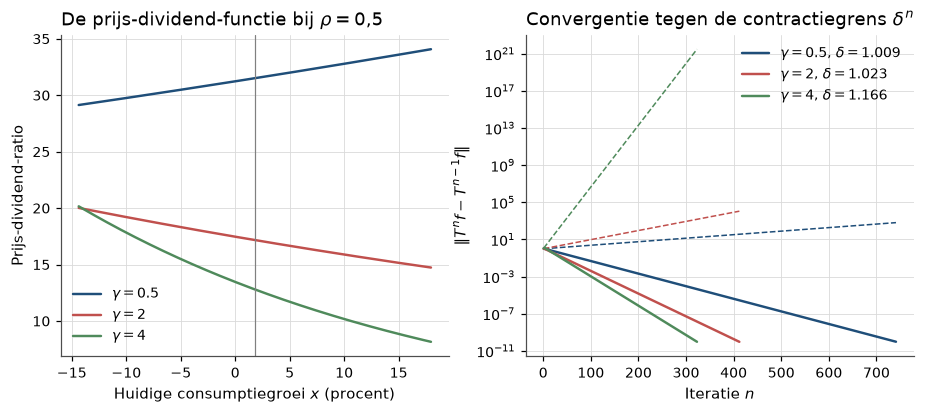

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for gamma_val in (0.5, 2.0, 4.0):
    grid, pd_fun, dist, delta = lucas_pd(beta_s, gamma_val, mu_s, 0.5, sigma_s)
    axes[0].plot(grid * 100, pd_fun, label=f"$\\gamma = {gamma_val:g}$")
    n = np.arange(1, len(dist) + 1)
    line, = axes[1].semilogy(n, dist, label=f"$\\gamma = {gamma_val:g}$, $\\delta = {delta:.3f}$")
    axes[1].semilogy(n, dist[0] * delta ** (n - 1), ls="--", lw=1, color=line.get_color())

axes[0].axvline(mu_s * 100, color="grey", lw=0.8)
axes[0].set_xlabel("Huidige consumptiegroei $x$ (procent)")
axes[0].set_ylabel("Prijs-dividend-ratio")
axes[0].set_title("De prijs-dividend-functie bij $\\rho = 0{,}5$")
axes[0].legend()
axes[1].set_xlabel("Iteratie $n$")
axes[1].set_ylabel("$\\|T^{n} f - T^{n-1} f\\|$")
axes[1].set_title("Convergentie tegen de contractiegrens $\\delta^{n}$")
axes[1].legend()
plt.show()

:::{figure} #cel-consumptie-capm-lucas
:label: fig-consumptie-capm-lucas
:width: 100%

Links: bij $\gamma < 1$ stijgt de prijs-dividend-ratio met de huidige groei
(hoge groei betekent hoge verwachte dividenden, en dat groei-effect domineert);
bij $\gamma > 1$ daalt hij (hoge groei betekent een hoge rente, en dat
disconteringseffect domineert). Bij $\gamma = 1$ heffen de twee elkaar precies
op. Rechts: de afstand tussen opeenvolgende iteraties (doorgetrokken) ligt onder
of op de meetkundige grens uit de contractiestelling (gestippeld).
:::

De linkerhelft is de continue versie van het toy-voorbeeld, en het is de moeite
waard te onthouden hoe gevoelig de *richting* is. Bij logaritmisch nut
($\gamma = 1$) hangt de prijs-dividend-ratio helemaal niet van de groei af — dat is
Rubinsteins resultaat, in één regel: $G^{1-\gamma} = 1$ in [](#eq-consumptie-capm-pd).
Of de ratio in een hoogconjunctuur stijgt of daalt, is dus een uitspraak over
$\gamma$. De data zeggen dat hij in hoogconjuncturen stijgt; een Lucas-boom met
$\gamma > 1$ en voorspelbare groei zegt het omgekeerde. Onthoud dat voor de
habit-, long-run-risk- en rampenmodellen van Deel V, die dit probleem elk op
een andere manier oplossen.

### GMM op gesimuleerde zeventigjaarssteekproeven

Nu de econometrie. We bouwen een wereld waarin de Euler-vergelijking *exact*
geldt en schatten $\beta$ en $\gamma$ zoals Hansen en Singleton het deden, maar dan
op een steekproef van zeventig jaar — ongeveer de lengte van de naoorlogse
Amerikaanse data. De wereld is de lognormale iid-boom uit
[](#prf-consumptie-capm-lognormaal) met jaarparameters $\mu = 1{,}8\%$,
$\sigma = 3{,}5\%$, $\beta = 0{,}98$, $\gamma = 4$, leverage $\lambda = 3$ en
idiosyncratisch dividendrisico $\sigma_d = 10\%$. Het aandeelrendement volgt uit
de gesloten vorm, de risicovrije rente is constant. Instrumenten: een constante,
vorige consumptiegroei en vorig aandeelrendement; twee activa; dus zes momenten
en een $J$-toets met vier vrijheidsgraden.

In [6]:
beta0, gamma0, mu_c, sigma_c, lev, sigma_d = 0.98, 4.0, 0.018, 0.035, 3.0, 0.10
k_mc = beta0 * np.exp(mu_c - gamma0 * mu_c + 0.5 * ((lev - gamma0) ** 2 * sigma_c**2 + sigma_d**2))
pd_mc = k_mc / (1 - k_mc)
rf_mc = 1 / (beta0 * np.exp(-gamma0 * mu_c + 0.5 * gamma0**2 * sigma_c**2))
premium_mc = np.exp(gamma0 * lev * sigma_c**2) - 1


def simulate_tree(n_years):
    """Consumption growth, stock return and risk-free return from the lognormal tree."""
    log_gc = rng.normal(mu_c, sigma_c, n_years)
    log_gd = mu_c + lev * (log_gc - mu_c) + sigma_d * rng.normal(size=n_years)
    gc = np.exp(log_gc)
    stock = (1 + pd_mc) / pd_mc * np.exp(log_gd)
    return gc, stock, np.full(n_years, rf_mc)


gc_big, rm_big, rf_big = simulate_tree(1_000_000)
print(f"PD = {pd_mc:.2f}, R^f = {rf_mc:.4f}, E[R^m]/R^f - 1 = {premium_mc:.4%}")
print(f"populatiecontrole E[m R^m] = {np.mean(beta0 * gc_big**-gamma0 * rm_big):.4f}, "
      f"E[m R^f] = {np.mean(beta0 * gc_big**-gamma0 * rf_big):.4f}")
print(f"std. dev. aandeelrendement = {rm_big.std():.4f}")

PD = 14.09, R^f = 1.0859, E[R^m]/R^f - 1 = 1.4809%
populatiecontrole E[m R^m] = 1.0000, E[m R^f] = 1.0002
std. dev. aandeelrendement = 0.1607


De risicopremie in deze wereld is 1,5% per jaar bij een aandeelvolatiliteit van
ongeveer 16%. Dat de risicovrije rente met 8,6% absurd hoog is, is geen fout in
de code: het is $\gamma\mu$ uit [](#eq-consumptie-capm-lognormaal), en het is een
voorproefje van [](#03-13-equity-premium-puzzle).

In [7]:
n_years, n_rep = 70, 500
mc_rows = []
for _ in range(n_rep):
    gc, rm, rf = simulate_tree(n_years + 1)
    Z = np.column_stack([np.ones(n_years), gc[:-1], rm[:-1]])
    res = gmm_euler(gc[1:], np.column_stack([rm, rf])[1:], Z, gamma_grid=np.linspace(-20, 60, 41))
    mc_rows.append(res)
mc = pd.DataFrame(mc_rows)

pd.DataFrame(
    {
        "waarheid": [gamma0, beta0, np.nan, 0.05],
        "5e pct": [mc.gamma.quantile(0.05), mc.beta.quantile(0.05), np.nan, np.nan],
        "mediaan": [mc.gamma.median(), mc.beta.median(), mc.se_gamma.median(), np.nan],
        "95e pct": [mc.gamma.quantile(0.95), mc.beta.quantile(0.95), np.nan, np.nan],
        "simulatie": [np.nan, (mc.beta > 1).mean(), mc.gamma.std(), (mc.p < 0.05).mean()],
    },
    index=["gamma-dak", "beta-dak (simulatie: aandeel > 1)",
           "SE gamma (mediaan) / spreiding gamma-dak", "J verwerpt op 5%"],
).round(3)

,waarheid,5e pct,mediaan,95e pct,simulatie
gamma-dak,4.00,-2.865,2.811,11.927,NaN
beta-dak (simulatie: aandeel > 1),0.98,0.880,0.958,1.110,0.286
SE gamma (mediaan) / spreiding gamma-dak,NaN,NaN,1.513,NaN,4.235
J verwerpt op 5%,0.05,NaN,NaN,NaN,0.098


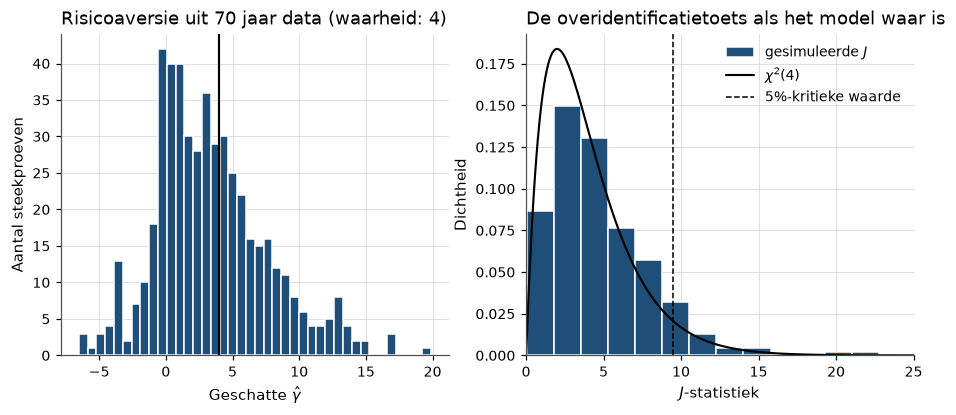

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].hist(mc.gamma.clip(-20, 30), bins=40, edgecolor="white")
axes[0].axvline(gamma0, color="black", lw=1.4)
axes[0].set_xlabel("Geschatte $\\hat\\gamma$")
axes[0].set_ylabel("Aantal steekproeven")
axes[0].set_title("Risicoaversie uit 70 jaar data (waarheid: 4)")

j_grid = np.linspace(0, 25, 300)
axes[1].hist(mc.J, bins=40, density=True, edgecolor="white", label="gesimuleerde $J$")
axes[1].plot(j_grid, stats.chi2.pdf(j_grid, 4), color="black", lw=1.4, label="$\\chi^2(4)$")
axes[1].axvline(stats.chi2.ppf(0.95, 4), color="black", ls="--", lw=1, label="5%-kritieke waarde")
axes[1].set_xlim(0, 25)
axes[1].set_xlabel("$J$-statistiek")
axes[1].set_ylabel("Dichtheid")
axes[1].set_title("De overidentificatietoets als het model waar is")
axes[1].legend()
plt.show()

:::{figure} #cel-consumptie-capm-mc
:label: fig-consumptie-capm-mc
:width: 100%

Links: 500 schattingen van $\gamma$, elk uit zeventig jaar data van een economie
waarin $\gamma = 4$ exact waar is. De verdeling is zo breed dat een onderzoeker
met één steekproef niet kan uitsluiten dat beleggers risiconeutraal zijn, en
evenmin dat ze drie keer zo risicomijdend zijn als de waarheid. Rechts: de
$J$-statistiek ligt verder naar rechts dan de asymptotische
$\chi^2(4)$-verdeling, zodat de toets een waar model vaker verwerpt dan de
nominale 5%.
:::

Drie dingen zijn hier te zien, en alle drie horen bij het 2%-motief. Het eerste
is de spreiding van $\hat\gamma$: tussen het 5e en het 95e percentiel loopt hij van
ongeveer $-3$ tot $12$, rond een waarheid van 4. Zonder voorspelbaarheid in de
instrumenten komt vrijwel alle informatie over $\gamma$ uit het gemiddelde excess
rendement, gedeeld door zijn covariantie met consumptie. De covariantie is goed
gemeten; het gemiddelde heeft bij 16% volatiliteit over zeventig jaar een
standaardfout van $16/\sqrt{70} \approx 1{,}9$ procentpunt — groter dan de premie
zelf. $\hat\gamma$ erft de onnauwkeurigheid van het slechtst gemeten getal in de
financiële economie. In bijna drie op de tien steekproeven komt $\hat\beta$
bovendien boven de één uit: via de rente zijn $\beta$ en $\gamma$ verknoopt, en een
te hoge $\hat\gamma$ wordt met een te hoge $\hat\beta$ gecompenseerd.

Het tweede is dat GMM die onnauwkeurigheid onderschat. De mediane gerapporteerde
standaardfout van $\hat\gamma$ is ongeveer 1,5, terwijl de werkelijke spreiding over
de steekproeven bijna drie keer zo groot is. De asymptotische formule gaat uit van
een schatter dicht bij de waarheid en van goed geschatte $\mathbf{D}$ en
$\mathbf{S}$; op zeventig waarnemingen geldt geen van beide.

Het derde is de omvang van de toets. Met zes momenten moet $\hat{\mathbf{S}}$ uit
zeventig waarnemingen worden geschat en geïnverteerd, wat de gewogen afstand
opblaast: de toets verwerpt een waar model in ongeveer één op de tien
steekproeven, twee keer de nominale 5%. Een verwerping met $p = 0{,}03$ op
zeventig jaar data zegt dus weinig. In de replicatie zullen de $p$-waarden van een
heel andere orde zijn.

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** Lars Peter Hansen en Kenneth Singleton, *Stochastic Consumption, Risk
Aversion, and the Temporal Behavior of Asset Returns*, Journal of Political
Economy 1983 {cite}`HansenSingleton1983`, en de GMM-aanpak uit
*Generalized Instrumental Variables Estimation of Nonlinear Rational
Expectations Models*, Econometrica 1982 {cite}`HansenSingleton1982`.

**Wat.** De schattingen van $\gamma$ en $\beta$ en de toets van de
overidentificerende restricties voor (a) alleen de risicovrije rente, (b) alleen
het aandelenrendement en (c) beide samen — de drie gevallen uit tabel 4, tabel 1
en tabel 5 van het paper uit 1983.

**Data hier.** FRED via `hap.data.fred`: reële consumptie per hoofd van
niet-duurzame goederen (`A796RX0Q048SBEA`) en diensten (`A797RX0Q048SBEA`), en de
bijbehorende prijsindices (`DNDGRD3Q086SBEA`, `DSERRD3Q086SBEA`), kwartaaldata.
Het marktrendement en de maandelijkse T-bill-rente komen uit Kenneth French via
`hap.data.market_monthly()`, samengesteld tot kwartalen en gedefleerd met de
impliciete prijsindex van niet-duurzaam plus diensten. Hoofdsteekproef
1947K2–2019K4; ter vergelijking 1959K2–1978K4.

**Verschil met het origineel.** Hansen en Singleton gebruikten maanddata
1959:2–1978:12, CRSP-rendementen, Ibbotson-Sinquefield T-bills, en schatten in
1983 met maximum likelihood onder een lognormaliteitsaanname; hun
GMM-schattingen uit 1982 zijn in een erratum gecorrigeerd
{cite}`HansenSingleton1984`, dat we niet hebben kunnen inzien. Wij gebruiken
kwartaaldata, GMM zonder verdelingsaanname, en één vertraging van
consumptiegroei, aandeelrendement en T-bill-rendement als instrumenten (zij
gebruikten twee tot zes). Het optellen van niet-duurzaam en diensten in
gekoppelde dollars is een benadering. De coronakwartalen van 2020 laten we uit
de hoofdsteekproef (zie oefening 3).

**Verwachte afwijking.** Puntschattingen wijken af, maar het *patroon* van de
tabellen uit 1983 moet terugkomen: (a) met alleen de T-bill een kleine en
redelijk precieze $\hat\gamma$ en een $J$-toets die verwerpt ($p < 0{,}01$);
(b) met alleen aandelen een $\hat\gamma$ met een standaardfout groter dan 2 en
géén verwerping; (c) met beide activa een verwerping. Het exact geïdentificeerde
systeem (aandelen en T-bill, alleen een constante) moet een $\gamma$ in de
tientallen vereisen of helemaal geen oplossing hebben. Draait (a) of (c) om,
dan zit er een fout in de code.
```

### De data

In [9]:
def fred_series(code):
    return hap_data.fred(code)[code]

cons = pd.DataFrame(
    {
        "nondurables": fred_series("A796RX0Q048SBEA"),   # real per capita, chained 2017 dollars
        "services": fred_series("A797RX0Q048SBEA"),
        "p_nondurables": fred_series("DNDGRD3Q086SBEA"),
        "p_services": fred_series("DSERRD3Q086SBEA"),
    }
)
cons["c"] = cons.nondurables + cons.services
cons["deflator"] = (cons.nondurables * cons.p_nondurables
                    + cons.services * cons.p_services) / cons.c
cons.index = cons.index.to_period("Q")

market = hap_data.market_monthly()
market_q = (1 + market[["Mkt", "RF"]]).groupby(market.index.to_period("Q")).prod()

quarterly = cons[["c", "deflator"]].join(market_q, how="inner")
inflation = quarterly.deflator / quarterly.deflator.shift(1)
quarterly["gc"] = quarterly.c / quarterly.c.shift(1)
quarterly["Rm"] = quarterly.Mkt / inflation
quarterly["Rf"] = quarterly.RF / inflation
quarterly = quarterly[["gc", "Rm", "Rf"]].dropna()
main = quarterly.loc[:"2019Q4"]

summary = pd.DataFrame(
    {
        "gemiddelde (%/kw)": main.sub([1, 1, 1]).mean() * 100,
        "std.dev. (%/kw)": main.std() * 100,
        "SE gemiddelde (%/kw)": main.std() / np.sqrt(len(main)) * 100,
        "corr. met c-groei": main.corr()["gc"],
    }
)
summary.loc["excess Rm - Rf"] = [
    (main.Rm - main.Rf).mean() * 100,
    (main.Rm - main.Rf).std() * 100,
    (main.Rm - main.Rf).std() / np.sqrt(len(main)) * 100,
    np.corrcoef(main.Rm - main.Rf, main.gc)[0, 1],
]
summary.index = ["consumptiegroei", "reëel marktrendement", "reëel T-bill-rendement", "excess rendement"]
print(f"steekproef {main.index[0]} t/m {main.index[-1]}, {len(main)} kwartalen")
summary.round(3)

steekproef 1947Q2 t/m 2019Q4, 291 kwartalen


,gemiddelde (%/kw),std.dev. (%/kw),SE gemiddelde (%/kw),corr. met c-groei
consumptiegroei,0.476,0.490,0.029,1.000
reëel marktrendement,2.200,7.978,0.468,0.147
reëel T-bill-rendement,0.174,0.648,0.038,0.161
excess rendement,2.026,7.991,0.468,0.134


De tabel bevat al het hele probleem. Consumptiegroei per hoofd heeft een
standaarddeviatie van ongeveer een half procent per kwartaal, het excess
rendement een van acht procent, en hun correlatie is laag. De covariantie tussen
de twee — het getal dat volgens [](#eq-consumptie-capm-ccapm) de premie moet
dragen — is dus minuscuul, terwijl de premie zelf twee procent per kwartaal is,
met een standaardfout van een half procentpunt.

### De schattingen

In [10]:
def estimate_table(frame):
    gc, rm, rf = frame.gc.to_numpy(), frame.Rm.to_numpy(), frame.Rf.to_numpy()
    Z = np.column_stack([np.ones(len(gc) - 1), gc[:-1], rm[:-1], rf[:-1]])
    specs = {
        "(a) T-bill": rf[1:, None],
        "(b) markt": rm[1:, None],
        "(c) markt + T-bill": np.column_stack([rm, rf])[1:],
    }
    rows = {name: gmm_euler(gc[1:], R, Z) for name, R in specs.items()}
    return pd.DataFrame(rows).T[["gamma", "se_gamma", "beta", "se_beta", "J", "df", "p"]]


tables = {
    "1947-2019": estimate_table(main),
    "1959-1978": estimate_table(quarterly.loc["1959Q2":"1978Q4"]),
}
gmm_results = pd.concat(tables, names=["steekproef", "activa"]).astype(float)
gmm_results.columns = ["gamma", "SE(gamma)", "beta", "SE(beta)", "J", "df", "p-waarde"]
gmm_results.round(4)

gamma  SE(gamma)    beta  SE(beta)        J  \
steekproef activa                                                              
1947-2019  (a) T-bill           0.4393     0.2393  1.0001    0.0013  57.6140   
           (b) markt           -0.3569     2.7283  0.9768    0.0145   3.1917   
           (c) markt + T-bill  17.3420     3.0786  1.0772    0.0168  42.1686   
1959-1978  (a) T-bill           0.5741     0.2385  1.0020    0.0016  24.1528   
           (b) markt           -2.0158     6.2326  0.9764    0.0447   3.8420   
           (c) markt + T-bill  -0.0241     0.5362  0.9930    0.0037  57.8946   

                                df  p-waarde  
steekproef activa                             
1947-2019  (a) T-bill          2.0    0.0000  
           (b) markt           2.0    0.2027  
           (c) markt + T-bill  6.0    0.0000  
1959-1978  (a) T-bill          2.0    0.0000  
           (b) markt           2.0    0.1465  
           (c) markt + T-bill  6.0    0.0000

Leg dit naast de tabellen van Hansen en Singleton uit 1983. Onthoud dat hun
$\hat\alpha$ gelijk is aan $-\gamma$ in onze notatie, en dat hun kolom
"probability" de waarde van de $\chi^2$-*verdelingsfunctie* is, niet de
$p$-waarde: een getal als .9999 betekent verwerping.

- **Alleen de T-bill** (hun tabel 4, p. 261): $\hat\alpha = -0{,}164$ (0,056) met
  niet-duurzaam en $\hat\alpha = -0{,}931$ (0,044) met niet-duurzaam plus
  diensten, bij NLAG = 2, met $\chi^2 = 27{,}34$ respectievelijk $30{,}08$ bij 3
  vrijheidsgraden en "probability" .9999. Kleine, precies geschatte
  risicoaversie; het model wordt verworpen. Onze rij (a) geeft hetzelfde beeld:
  $\hat\gamma$ rond een half met een standaardfout van ongeveer 0,24, en een
  $J$-statistiek die de restricties verwerpt in beide steekproeven.
- **Alleen aandelen** (hun tabel 1, p. 259): voor het value-weighted
  NYSE-rendement bijvoorbeeld $\hat\alpha = -1{,}25$ (0,647) en
  $\hat\beta = 0{,}9993$ (0,0030) voor model 3 (niet-duurzaam, NLAG = 6), en
  $\hat\alpha = -1{,}509$ (1,571) met $\hat\beta = 1{,}0007$ (0,0042) voor model 6
  (niet-duurzaam plus diensten, NLAG = 6), met $\chi^2(11) = 10{,}622$ en
  $10{,}932$ — geen verwerping. Onze rij (b): een standaardfout van $\hat\gamma$
  die groter is dan de schatting zelf, en geen verwerping.
- **Aandelen en T-bill samen** (hun tabel 5, p. 262): met NLAG = 4 is
  $\chi^2(24) = 170{,}25$ (niet-duurzaam) en $366{,}22$ (plus diensten), beide
  met "probability" .9999. Onze rij (c) verwerpt eveneens. In de naoorlogse
  steekproef tot 2019 gebeurt dat bovendien met een $\hat\gamma$ boven de tien
  en een $\hat\beta$ boven de één: de schatter probeert de premie te
  verklaren met hoge risicoaversie, en moet dan het ongeduld omdraaien om de
  lage rente te blijven raken.

De verwachte afwijking uit het replicatieblok komt dus uit in alle drie de
gevallen. Belangrijker dan de afzonderlijke getallen is het contrast met de
simulatie: daar verwierp de toets een waar model in ongeveer één op de tien
steekproeven; hier liggen de $p$-waarden voor (a) en (c) onder $10^{-5}$.

### Wat het aandelenrendement alleen vraagt

Hansen en Singleton rapporteerden in tabel 5 ook de versie zonder vertraagde
instrumenten (NLAG = 0), waarin twee momenten twee parameters exact vastleggen.
Dat is de versie van Grossman en Shiller, en ze gaf $\hat\alpha = -30{,}58$
(34,06) met $\hat\beta = 1{,}001$ (0,0462) voor niet-duurzaam, en
$\hat\alpha = -58{,}25$ (66,57) met $\hat\beta = 1{,}088$ (0,0687) voor
niet-duurzaam plus diensten. Het exact geïdentificeerde systeem hangt in feite
aan één vergelijking, want $\beta$ valt weg uit het verschil van de twee
Euler-vergelijkingen:

```{math}
:label: eq-consumptie-capm-excess
0 = \E\!\left[\left(\frac{c_{t+1}}{c_t}\right)^{-\gamma} \left(R^m_{t+1} - R^f_{t+1}\right)\right].
```

Bij $\gamma = 0$ is de rechterkant het gemiddelde excess rendement. Naarmate
$\gamma$ stijgt, krijgen kwartalen met lage consumptiegroei meer gewicht, en als
aandelen in die kwartalen slecht renderen, daalt de gewogen premie. De vraag is
bij welke $\gamma$ hij nul wordt.

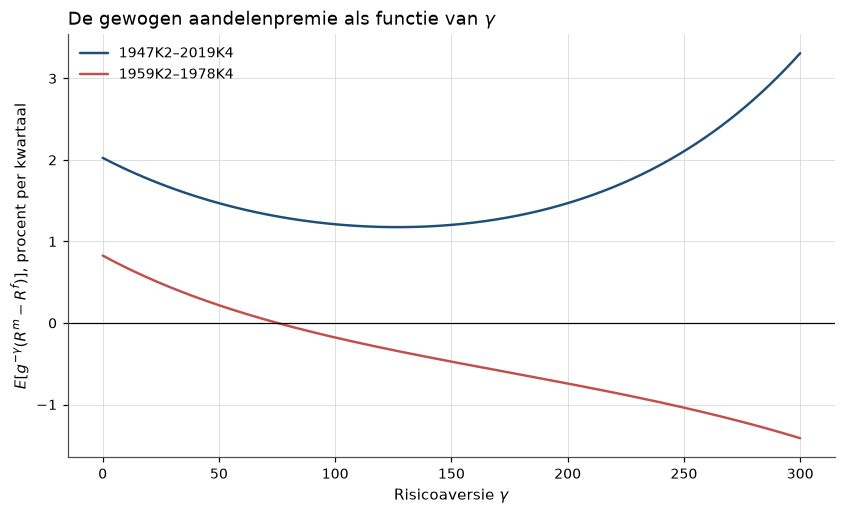

{'1947K2–2019K4': nan, '1959K2–1978K4': 75.2}

In [11]:
gamma_line = np.linspace(0, 300, 601)
fig, ax = plt.subplots()
roots = {}
for label, frame in [("1947K2–2019K4", main), ("1959K2–1978K4", quarterly.loc["1959Q2":"1978Q4"])]:
    gc, excess = frame.gc.to_numpy(), (frame.Rm - frame.Rf).to_numpy()
    weighted = np.array([np.mean(gc ** (-x) * excess) for x in gamma_line]) * 100
    ax.plot(gamma_line, weighted, label=label)
    crossing = np.flatnonzero(np.diff(np.sign(weighted)))
    roots[label] = (optimize.brentq(lambda x: np.mean(gc ** (-x) * excess), gamma_line[crossing[0]],
                                    gamma_line[crossing[0] + 1]) if crossing.size else np.nan)
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Risicoaversie $\\gamma$")
ax.set_ylabel("$E[g^{-\\gamma}(R^m - R^f)]$, procent per kwartaal")
ax.set_title("De gewogen aandelenpremie als functie van $\\gamma$")
ax.legend()
plt.show()

{label: round(value, 1) for label, value in roots.items()}

:::{figure} #cel-consumptie-capm-excess
:label: fig-consumptie-capm-excess
:width: 90%

De steekproefversie van [](#eq-consumptie-capm-excess). Een waarde boven nul
betekent dat aandelen bij die $\gamma$ te veel opleveren voor het risico dat ze
volgens het model dragen. In de steekproef 1959–1978 snijdt de lijn de nul pas
bij een risicoaversie in de tientallen; in de naoorlogse steekproef tot 2019
snijdt hij haar nergens, en begint de lijn bij hoge $\gamma$ weer te stijgen
omdat een handvol kwartalen met dalende consumptie en stijgende koersen het
gewicht overneemt.
:::

Dat is dezelfde uitkomst als in hun tabel 5, en ook de orde van grootte klopt:
in de steekproef die met die van Hansen en Singleton overlapt, is
$\gamma \approx 75$ nodig om de gemiddelde premie te verklaren. In de langere steekproef
bestaat er geen $\gamma$ die het doet. De standaardfouten van 34 en 67 in hun
tabel zijn het 2%-motief in zijn scherpste vorm: omdat de premie slecht gemeten
is, is de risicoaversie die hem moet verklaren nog slechter gemeten, en toch is
zelfs de onderkant van dat brede interval onaannemelijk groot.

```{warning}
Consumptie is een kwartaalgemiddelde, rendementen zijn punt-tot-punt. Die
tijdsaggregatie maakt de Euler-fout autocorrelerend (ongeveer MA(1)), zodat de
standaardfouten hierboven te klein en de $J$-statistieken te groot zijn. Hansen
en Singleton kozen daarom maanddata, en waarschuwden dat die grotendeels
geïnterpoleerd zijn. Het verklaart niet de omvang van de verwerping, en niet
waarom de premie een $\gamma$ in de tientallen vergt.
```

## Wat er brak, en wat daarna kwam

**Wat het model verklaart.** Meer dan elk model hiervoor. Het consumption CAPM
geeft voor het eerst een theorie van de discontovoet: waarom rentes hoog zijn als
groei verwacht wordt, waarom verzekeringen een negatief verwacht excess rendement
hebben, waarom een activum dat in recessies goed rendeert weinig hoeft op te
brengen, en waarom de prijs-dividend-ratio kan bewegen zonder dat dividenden dat
doen. Het verenigt de CAPM-logica met Mertons intertemporele hedging in één
bèta, het maakt van [](#eq-consumptie-capm-euler) een vergelijking die elk
later model zal hergebruiken, en het leverde met GMM een schattingsmethode op
die tot op vandaag de standaard is voor elk model dat als momentvoorwaarde kan
worden geschreven.

**Waar het breekt.** Op het meetbare punt dat we hierboven zelf hebben gezien:
één paar $(\beta, \gamma)$ kan de risicovrije rente en het aandelenrendement niet
tegelijk prijzen. De $J$-toets met aandelen en T-bill samen verwerpt met
$p$-waarden ver onder één promille, en de gemiddelde aandelenpremie vraagt een
risicoaversie in de tientallen — of, over 1947–2019 op kwartaaldata, is met
geen enkele $\gamma$ te verklaren. De simulatie laat zien dat dit geen
kleine-steekproefartefact is: in een wereld waarin het model waar is, zijn de
schattingen onnauwkeurig maar is de verwerping zeldzaam en zwak.

**Risico of vergissing?** De Chicago-lezing: de theorie is juist, maar de
specificatie is te arm. Consumptie wordt slecht gemeten, beleggers zijn niet
representatief (de meeste huishoudens hadden geen aandelen), en tijd-separabel
CRRA-nut koppelt risicoaversie mechanisch aan de bereidheid om consumptie over
de tijd te verschuiven. Laat die koppeling of de iid-aanname los, voeg gewoontes
of zeldzame rampen toe, en de discontovoet kan wél zo sterk variëren als de
prijzen vereisen — het risico is echt, alleen verborgen in een deel van de
verdeling dat zeventig jaar data niet goed laat zien. De Yale-lezing: prijzen
worden niet gezet door consumptie-afvlakkende huishoudens maar door beleggers
met beperkte aandacht, institutionele beperkingen en wisselende stemmingen;
de premie is niet de beloning voor consumptierisico maar een vergoeding voor
angst en een correctie van vergissingen, en een Euler-vergelijking met
geaggregeerde consumptie is simpelweg de verkeerde plek om die te zoeken. De
data die de twee kampen zouden kunnen scheiden — nauwkeurige consumptie van de
huishoudens die daadwerkelijk aandelen bezitten, over een eeuw — bestaan niet in
de vereiste lengte.

**Wat er daarna kwam.** Mehra en Prescott maakten van de breuk in 1985 een
kwantitatieve puzzel en Hansen en Jagannathan maakten er een grens van die
voor elk SDF-model geldt; zie [](#03-13-equity-premium-puzzle).

Noteer ook hier de epistemische status. Het consumption CAPM is de eerste theorie
in deze reeks die precies genoeg zegt om met één getal te worden verworpen, en
dat is gebeurd. Wat het vak daarna deed, was niet de theorie weggooien maar de
vergelijking $p = \E[mx]$ behouden en de vraag welke $m$ openbreken. Daarmee
begint de verschuiving van één getoetste theorie naar een raamwerk waarin
concurrerende modellen elk een andere $m$ voorstellen.

## Oefeningen

:::{exercise}
:label: ex-consumptie-capm-1

**Persistentie, risicoaversie en de richting van de prijs-dividend-ratio.** Neem
het toy-voorbeeld ($g_h = 1{,}04$, $g_l = 0{,}98$, $\beta = 0{,}96$) met
symmetrische overgangskans $\pi = P_{hh} = P_{ll}$.

1. Laat analytisch zien dat bij $\gamma = 1$ de prijs-dividend-ratio in beide
   toestanden gelijk is aan $\beta/(1-\beta)$, ongeacht $\pi$.
2. Laat zien dat bij $\pi = 1/2$ (iid groei) de ratio voor elke $\gamma$ in beide
   toestanden gelijk is.
3. Bereken $\mathrm{PD}_h - \mathrm{PD}_l$ en de contractiemodulus $\delta$ uit
   [](#thm-consumptie-capm-contractie) voor $\gamma \in \{0{,}5;\ 1;\ 2;\ 4\}$
   en $\pi \in \{0{,}5;\ 0{,}75;\ 0{,}9\}$. Voor welke combinaties is de ratio
   procyclisch (hoger in de hoge toestand)?
:::

:::{solution} ex-consumptie-capm-1
:class: dropdown

**(1)** Bij $\gamma = 1$ is $g_j^{1-\gamma} = 1$, dus
$\mathrm{PD}_i = \beta \sum_j P_{ij}(1 + \mathrm{PD}_j)$. De constante
$\mathrm{PD} = \beta(1 + \mathrm{PD})$ lost dit op, dus
$\mathrm{PD} = \beta/(1-\beta) = 24$; uniciteit volgt uit de contractiestelling
($\delta = \beta < 1$).

**(2)** Bij $\pi = 1/2$ zijn beide rijen van $P$ gelijk, dus het rechterlid van
[](#eq-consumptie-capm-pd) hangt niet van $i$ af; het vaste punt is dan
constant.

**(3)**

In [12]:
def toy_pd(gamma, pi, beta=0.96, g=np.array([1.04, 0.98])):
    trans = np.array([[pi, 1 - pi], [1 - pi, pi]])
    kernel = beta * trans * g ** (1 - gamma)
    pd_states = np.linalg.solve(np.eye(2) - kernel, kernel @ np.ones(2))
    radius = np.abs(np.linalg.eigvals(kernel)).max()
    return pd_states[0] - pd_states[1], kernel.sum(axis=1).max(), radius

rows_ex1 = []
for gm in (0.5, 1.0, 2.0, 4.0):
    for pi in (0.5, 0.75, 0.9):
        diff, delta, radius = toy_pd(gm, pi)
        rows_ex1.append({"gamma": gm, "pi": pi, "PD_h - PD_l": diff,
                         "delta": delta, "spectraalstraal": radius})
pd.DataFrame(rows_ex1).set_index(["gamma", "pi"]).round(4)

PD_h - PD_l   delta  spectraalstraal
gamma pi                                        
0.5   0.50       0.0000  0.9647           0.9647
      0.75       0.7882  0.9718           0.9649
      0.90       2.9033  0.9761           0.9655
1.0   0.50      -0.0000  0.9600           0.9600
      0.75       0.0000  0.9600           0.9600
      0.90      -0.0000  0.9600           0.9600
2.0   0.50       0.0000  0.9513           0.9513
      0.75      -1.1250  0.9655           0.9522
      0.90      -4.1143  0.9739           0.9546
4.0   0.50       0.0000  0.9367           0.9367
      0.75      -2.7592  0.9783           0.9440
      0.90     -12.9169  1.0033           0.9627

De ratio is procyclisch precies wanneer $\gamma < 1$ en $\pi > 1/2$: dan domineert
het groei-effect. Bij $\gamma > 1$ domineert de rente, en het verschil wordt
groter naarmate groei persistenter is. Bij $\gamma = 4$ en $\pi = 0{,}9$ is
$\delta = 1{,}0033 > 1$: de voorwaarde van [](#thm-consumptie-capm-contractie) is
geschonden, en toch bestaat er een eindige oplossing. De voorwaarde is voldoende,
niet nodig; wat voor een eindige toestandsruimte werkelijk telt, is dat de
spectraalstraal van de matrix $\beta P_{ij} g_j^{1-\gamma}$ kleiner is dan één
(hier $0{,}963$). In de supremumnorm is $T$ dan geen contractie in één stap, maar
een macht $T^n$ is dat wel. Wat de oefening over het hoofdargument leert: in een
Lucas-economie is de *richting* waarin prijzen op goed nieuws reageren een
uitspraak over voorkeuren, en een procyclische prijs-dividend-ratio vraagt ofwel
$\gamma < 1$ ofwel een ander model.
:::

:::{exercise}
:label: ex-consumptie-capm-2

**De gesloten vorm narekenen.** Gebruik de simulatie-economie ($\beta = 0{,}98$,
$\gamma = 4$, $\mu = 1{,}8\%$, $\sigma = 3{,}5\%$, $\lambda = 3$,
$\sigma_d = 10\%$).

1. Leid uit [](#eq-consumptie-capm-lognormaal) de consumptiebèta van het
   log-aandeelrendement af, $\Cov(\log R^m, \Delta c)/\Var(\Delta c)$, en laat zien
   dat [](#eq-consumptie-capm-ccapm) voor log-rendementen de vorm
   $\E[\log R^m] - \log R^f + \tfrac12\Var(\log R^m) = \gamma\,\Cov(\log R^m, \Delta c)$
   heeft.
2. Controleer beide kanten numeriek op één miljoen gesimuleerde jaren.
3. Hoeveel jaar data is nodig om de premie met een $t$-waarde van twee te
   onderscheiden van nul?
:::

:::{solution} ex-consumptie-capm-2
:class: dropdown

**(1)** Omdat $\mathrm{PD}$ constant is, is $\log R^m = \log\frac{1+\mathrm{PD}}{\mathrm{PD}} + \log g^d$,
dus $\Cov(\log R^m, \Delta c) = \lambda\sigma^2$ en de bèta is $\lambda = 3$. Uit
[](#eq-consumptie-capm-lognormaal) is $\log \E[R^m] - \log R^f = \gamma\lambda\sigma^2$;
voor een lognormale $R^m$ is $\log \E[R^m] = \E[\log R^m] + \tfrac12\Var(\log R^m)$,
wat de gevraagde vorm geeft met rechterlid $\gamma\lambda\sigma^2 = 0{,}0147$.

**(2) en (3)**

In [13]:
log_rm = np.log(rm_big)
lhs = log_rm.mean() - np.log(rf_mc) + 0.5 * log_rm.var()
rhs = gamma0 * np.cov(log_rm, np.log(gc_big))[0, 1]
beta_c = np.cov(log_rm, np.log(gc_big))[0, 1] / np.log(gc_big).var()

excess = rm_big - rf_big
years_needed = (2 * excess.std() / excess.mean()) ** 2

print(f"consumptiebeta van log R^m : {beta_c:.3f}   (theorie: 3)")
print(f"linkerlid                  : {lhs:.5f}")
print(f"rechterlid                 : {rhs:.5f}   (theorie: {gamma0 * lev * sigma_c**2:.5f})")
print(f"jaren nodig voor t = 2     : {years_needed:.0f}")

consumptiebeta van log R^m : 3.000   (theorie: 3)
linkerlid                  : 0.01449
rechterlid                 : 0.01472   (theorie: 0.01470)
jaren nodig voor t = 2     : 411


Het linkerlid ($0{,}0145$) en het rechterlid ($0{,}0147$) verschillen met
$0{,}0002$, ongeveer anderhalve standaardfout van een gemiddelde over een miljoen
jaar met 16% volatiliteit. Voor $t = 2$ is $T = (2\sigma_{R^e}/\E[R^e])^2$ nodig;
met een excess volatiliteit van 16% en een gemiddeld excess rendement van 1,6%
zijn dat ongeveer vierhonderd jaar. Wat de oefening over het hoofdargument leert: de
consumptiebèta is scherp te meten, de premie niet — en daarom erft $\hat\gamma$ de
onnauwkeurigheid van de premie en niet die van de bèta.
:::

:::{exercise}
:label: ex-consumptie-capm-3

**De replicatie op jaardata en met de coronakwartalen.** Herhaal de schatting
van specificatie (c) (markt en T-bill, instrumenten: constante en één
vertraging van alle drie de variabelen)

1. op kwartaaldata tot en met de laatste beschikbare waarneming, dus inclusief
   2020–2026;
2. op jaardata 1948–2019, met consumptie als jaargemiddelde van de
   kwartaalreeks en rendementen samengesteld over het kalenderjaar.

Rapporteer $\hat\gamma$, $\hat\beta$, $J$ en de $p$-waarde. Verandert de
conclusie?
:::

:::{solution} ex-consumptie-capm-3
:class: dropdown

In [14]:
annual_cons = cons.loc[:"2019Q4", ["c", "deflator"]].groupby(lambda q: q.year).mean()
market_a = (1 + market[["Mkt", "RF"]]).groupby(market.index.year).prod()
annual = annual_cons.join(market_a, how="inner")
infl_a = annual.deflator / annual.deflator.shift(1)
annual["gc"] = annual.c / annual.c.shift(1)
annual["Rm"] = annual.Mkt / infl_a
annual["Rf"] = annual.RF / infl_a
annual = annual[["gc", "Rm", "Rf"]].dropna()

variants = {
    "kwartaal 1947-2019": main,
    "kwartaal incl. 2020-": quarterly,
    "jaar 1948-2019": annual,
}
rows_ex3 = {}
for name, frame in variants.items():
    table = estimate_table(frame)
    rows_ex3[name] = table.loc["(c) markt + T-bill"]
pd.DataFrame(rows_ex3).T.astype(float).round(4)

,gamma,se_gamma,beta,se_beta,J,df,p
kwartaal 1947-2019,17.3420,3.0786,1.0772,0.0168,42.1686,6.0,0.0
kwartaal incl. 2020-,2.2678,0.7862,1.0073,0.0042,40.7537,6.0,0.0
jaar 1948-2019,-2.3172,0.6257,0.9323,0.0129,30.4332,6.0,0.0


De puntschatting van $\gamma$ springt van ongeveer 17 (kwartalen tot 2019) naar
ongeveer 2 (met de coronakwartalen, waarin consumptie binnen een half jaar bijna
tien procent daalde en weer steeg, en die daardoor een enorm gewicht krijgen in
$g^{-\gamma}$) en naar een *negatieve* waarde op jaardata. De verwerping blijft in
alle drie de varianten, telkens met een $p$-waarde ver onder één promille. Wat de
oefening over het hoofdargument leert: $\hat\gamma$ is niet robuust tegen
frequentie, steekproef of een paar uitschieters, de verwerping wel — de breuk zit
niet in een detail van de meting maar in de restricties zelf.
:::